# M1.Ex3: Iris Classification

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex3_class.ipynb)
- Dataset:`sklearn.datasets.load_iris()`

In [1]:
import pandas as pd
import sklearn

![Iris Flowers](../assets/iris_flowers.png)

### Step 1.a Load the data

In [2]:
iris = sklearn.datasets.load_iris(as_frame=True)

### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
X, y = iris.data, iris.target

### Step 2.b print the type of each

In [4]:
X.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
dtype: object

In [5]:
y.dtype

dtype('int64')

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

- Categorical target
- So: classification task

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [6]:
# Data Matrix
X.shape

(150, 4)

In [7]:
y.shape

(150,)

### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [8]:
X.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
y.describe()

count    150.000000
mean       1.000000
std        0.819232
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max        2.000000
Name: target, dtype: float64

### Step 5. Plot the features to identify separability. Can you see clearly distinguishable groups of points?

In [13]:
full_df = pd.concat([X, y], axis=1)

# Map the integer values to the actual flower names for better plots and readability
full_df['target'] = full_df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
full_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


Text(0.5, 1.0, 'Petal Length vs Petal Width')

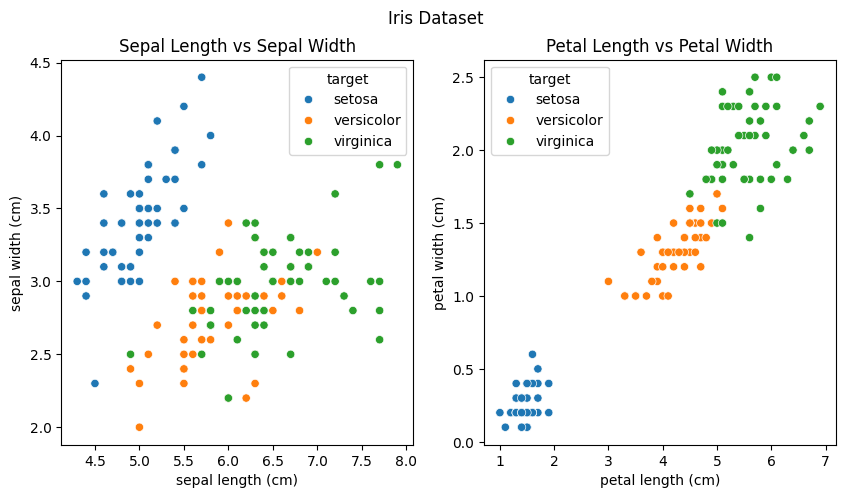

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sns.scatterplot(
    data=full_df,
    x='sepal length (cm)',
    y='sepal width (cm)',
    hue='target',
    ax=ax[0]
)
sns.scatterplot(
    data=full_df,
    x='petal length (cm)',
    y='petal width (cm)',
    hue='target',
    ax=ax[1]
)

fig.suptitle("Iris Dataset")

ax[0].set_title("Sepal Length vs Sepal Width")
ax[1].set_title("Petal Length vs Petal Width")

# plt.tight_layout()

### Step 6. Keep the following in "Steps 7" onwards

1. First model will trian on the features: `sepal length (cm)` & `sepal width (cm)`
2. Second model will train on the features: `petal length (cm)` & `petal width (cm)`

Finally, evaluate and compare which of the two feature-sets scored better.

Let's do both subsets now..

### Step 6.a subset the features `sepal length (cm)` & `sepal width (cm)`


In [15]:
X_sepal = X[['sepal length (cm)', 'sepal width (cm)']]

### Step 6.b subset the features `petal length (cm)` & `petal width (cm)`


In [16]:
X_petal = X[['petal length (cm)', 'petal width (cm)']]

### Step 7. Initialize 2 `LogisticRegression` models

In [17]:
from sklearn.linear_model import LogisticRegression

lr_sepal = LogisticRegression()
lr_petal = LogisticRegression()

### Step 8. Split the dataset into train and test sets (remember to stratify by the target to account for class imbalance)

In [18]:
from sklearn.model_selection import train_test_split

X_sepal_train, X_sepal_test, y_sepal_train, y_sepal_test = train_test_split(
    X_sepal, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_petal_train, X_petal_test, y_petal_train, y_petal_test = train_test_split(
    X_petal, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Step 9.a Train both models

In [19]:
lr_sepal.fit(X_sepal_train, y_sepal_train)
lr_petal.fit(X_petal_train, y_petal_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Step 10. Evaluate and compare both models

In [20]:
score_sepal = lr_sepal.score(X_sepal_test, y_sepal_test)

In [21]:
score_petal = lr_petal.score(X_petal_test, y_petal_test)

### Step 11. Which of the two subset of features better distinguishes iris flowers? Can you easily tell?

In [22]:
print(f"Score of sepal model: {score_sepal}")
print(f"Score of petal model: {score_petal}")

better_score = max(score_sepal, score_petal)
better_score

Score of sepal model: 0.7333333333333333
Score of petal model: 0.9666666666666667


0.9666666666666667

Since the score is higher, we conclude that petal is more predictive of the type of flower than the sepal.

### Step 12. Use `DecisionBoundaryDisplay` to plot the learned decision boundary

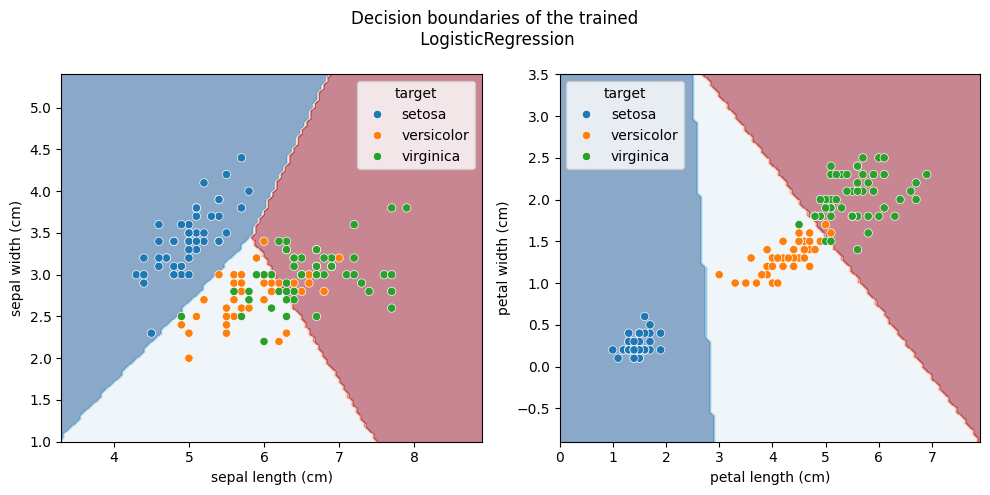

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import DecisionBoundaryDisplay

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

DecisionBoundaryDisplay.from_estimator(
    lr_sepal,
    X_sepal,
    response_method="predict",
    cmap="RdBu_r",
    alpha=0.5,
    ax=ax[0]
)

sns.scatterplot(
    data=full_df,
    x='sepal length (cm)',
    y='sepal width (cm)',
    hue='target',
    ax=ax[0]
)

DecisionBoundaryDisplay.from_estimator(
    lr_petal,
    X_petal,
    response_method="predict",
    cmap="RdBu_r",
    alpha=0.5,
    ax=ax[1]
)

sns.scatterplot(
    data=full_df,
    x='petal length (cm)',
    y='petal width (cm)',
    hue='target',
    ax=ax[1]
)

fig.suptitle("Decision boundaries of the trained\n LogisticRegression")

plt.tight_layout()


## Extra: let's use all features to see if accuracy gets better

In [28]:
X_all = X[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
lr_all = LogisticRegression()
lr_all.fit(X_all, y)
score_all = lr_all.score(X_all, y)

/home/halgoz/work/AthkaX/ai-pros/public/content/W3/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
score_all

0.9733333333333334

In [33]:
X_all = X[['petal length (cm)']]
lr_all = LogisticRegression()
lr_all.fit(X_all, y)
score_all = lr_all.score(X_all, y)
score_all

0.9533333333333334

In [34]:
X_all = X[['petal width (cm)']]
lr_all = LogisticRegression()
lr_all.fit(X_all, y)
score_all = lr_all.score(X_all, y)
score_all

0.96

The `4%` off may be explained by the histogram overlap. Let's plot it to see:

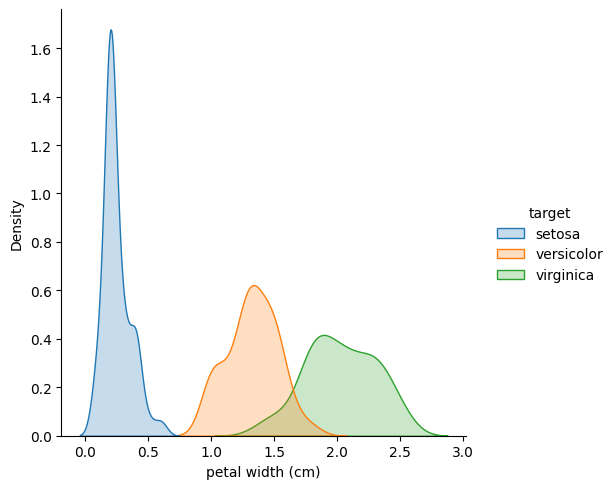

: 

In [ ]:
sns.displot(
    data=full_df,
    x='petal width (cm)',
    kind='kde',
    hue='target',
    fill=True,
)